---
tags: [algorithm, encoding, resource-estimation]
---

# 量子特異値変換

量子特異値変換（Quantum Singular Value Transformation; QSVT）{cite:p}`10.1145/3313276.3316366`は、より大きなユニタリに埋め込んだ行列の特異値に対して多項式を作用させる手法です。本記事では、非エルミートな$2\times2$行列のブロックエンコーディングを構築し、`qmc.qsvt`で2次のチェビシェフ多項式を適用して、変換後の行列と論理リソース推定を検証します。

In [1]:
# Install the latest Qamomile through pip!
# !pip install "qamomile[qiskit,visualization]"

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
from qiskit.quantum_info import Operator

import qamomile.circuit as qmc
from qamomile.linalg import PauliLCU
from qamomile.qiskit import QiskitTranspiler

## 背景

### 量子信号処理（QSP）

量子信号処理（Quantum Signal Processing; QSP）{cite:p}`10.1103/PhysRevLett.118.010501`は、1量子ビットのユニタリに符号化されたスカラー値$x\in[-1,1]$に対して多項式変換を行います。QSPは、信号ユニタリと位相回転の交互積によって構成されます。代表的な規約の一つでは、信号ユニタリを次のように定義します。

$$
W(x)=e^{i\arccos(x)X}
=\begin{pmatrix}
x & i\sqrt{1-x^2}\\
i\sqrt{1-x^2} & x
\end{pmatrix}.
$$

QSPでは、信号ユニタリの間に制御可能な$Z$軸まわりの位相回転を適用します。

$$
S(\phi)=e^{i\phi Z}
=\operatorname{diag}(e^{i\phi},e^{-i\phi}).
$$

位相列$\Phi=(\phi_0,\phi_1,\ldots,\phi_d)$によって、次の交互積が定まります。

$$
U_\Phi(x)
=S(\phi_0)\prod_{j=1}^{d}\left(W(x)S(\phi_j)\right).
$$

左上成分$\langle0|U_\Phi(x)|0\rangle=P_\Phi(x)$は$x$の多項式です。実多項式$p(x)$は、次の条件を満たすとき$\operatorname{Re}[P_\Phi(x)]$として表現できます。

- 次数が$d$以下であること。
- 偶奇性が$d$と一致すること、すなわち$p(-x)=(-1)^d p(x)$であること。
- 信号区間上で有界であること、すなわち$x\in[-1,1]$に対して$|p(x)|\leq1$であること。

QSPの設計では、まず目標の関数$p(x)$をこの条件を満たす多項式で近似し、対応する位相列を古典計算で合成します。次数$d$の変換は信号ユニタリを$d$回使うため、多項式の次数が問い合わせ計算量を決めます。

QSVTは、このスカラー多項式変換をブロックエンコーディングされた行列の各特異値部分空間へ拡張します。

### ブロックエンコーディング

QSPを行列の特異値部分空間へと拡張する前に、量子計算において、ユニタリでない行列を扱う方法について説明します。ブロックエンコーディングは、与えられた（ユニタリでない）行列をより大きなユニタリ行列の一部に埋め込む手法です。

$A$が$n$量子ビットの系レジスタに作用するとします。$(\alpha,a)$ブロックエンコーディングは、追加の$a$量子ビットの信号レジスタに作用するユニタリ$U$で、次を満たします。

$$
(\langle 0|^{\otimes a}\otimes I)U
(|0\rangle^{\otimes a}\otimes I)=\frac{A}{\alpha}.
$$

ここで、$\alpha$は$\alpha\geq\lVert A\rVert_2$を満たす正規化係数です。埋め込まれるブロックは$A/\alpha$であるため、QSVTは区間$[0,1]$の特異値に作用します。$\alpha$の値によって、回路が実現する多項式と、最終的に$A$へ適用される関数との尺度が定まります。

ブロックエンコーディングは、一般には非ユニタリな行列演算をユニタリ発展の一部として表現します。$U$の前後で信号レジスタを$|0\rangle^{\otimes a}$へ射影すると、埋め込まれた行列ブロックが選択されます。この共通の構成により、行列自体がユニタリまたはエルミートでなくても、QSVTでその特異値を操作できます。

ブロックエンコーディングの代表的な構成法には、次のものがあります。

- **スパースアクセスオラクル**：スパース行列の非ゼロ要素について、その位置と値を重ね合わせのまま取得します。これらのオラクルを組み合わせると、正規化されたスパース行列を射影ブロックに持つユニタリを構成できます。
- **ユニタリの線形結合（LCU）**：$A=\sum_j c_j U_j$を効率的に実装できるユニタリの重み付き和として表し、補助レジスタの振幅に$c_j$を反映して$U_j$を選択します。このレジスタを射影すると、$A/\sum_j|c_j|$が得られます。

このほか、状態準備手続きや量子読み出し専用メモリ（QROM）に格納されたデータからもブロックエンコーディングを構成できます。

## アルゴリズム

$U$を行列$A$の$(\alpha,a)$ブロックエンコーディングとし、$A$の特異値分解を

$$
A=W\Sigma V^\dagger
$$

とします。信号部分空間への射影を次のように定義します。

$$
\Pi=|0\rangle\!\langle0|^{\otimes a}\otimes I.
$$

この部分空間に関する位相付き反射は次のように表せます。

$$
R_\Pi(\phi)=\exp\!\left(i\phi(2\Pi-I)\right).
$$

QSVTでは、$U$と$U^\dagger$をこれらの位相回転と交互に適用します。位相列を

$$
\Phi=(\phi_0,\phi_1,\ldots,\phi_d)
$$

とすると、得られる積は各特異値$\sigma_j/\alpha$に対応する2次元不変部分空間で独立に作用します。位相を適切に選ぶことで、射影後の応答を多項式$P(\sigma_j/\alpha)$にできます。

$P$の偶奇性によって、左特異ベクトル空間と右特異ベクトル空間の関係が決まります。上記の特異値分解に対する特異値変換は次のようになります。

$$
P^{(\mathrm{SV})}(A/\alpha)=
\begin{cases}
W P(\Sigma/\alpha)V^\dagger, & P\text{が奇関数},\\
V P(\Sigma/\alpha)V^\dagger, & P\text{が偶関数}.
\end{cases}
$$

したがって、QSVTアルゴリズムは次の手順で構成されます。

1. 入力行列に対して正規化されたブロックエンコーディングを選びます。
2. 目標のスカラー関数を、必要な偶奇性を持つ有界な多項式で近似します。
3. その多項式に対応する位相列を古典計算で合成します。
4. ブロックエンコーディング、その随伴、射影位相回転を交互に適用します。
5. 信号部分空間へ射影し、目的の特異値変換を得ます。

QSP/QSVTでは、文献や実装によって位相の定義や演算を適用する順番が異なる場合があります。したがって、ある規約で求めた位相列を使用するときは、回路も同じ規約に従って構成する必要があります。

## Qamomileの実装

このセクションでは、LCUを使って非エルミート行列のブロックエンコーディングを構築し、それにQSVTを適用する量子カーネルをQamomileで作成します。その後、量子カーネルを描画し、数値検証に用いるQiskit回路へ変換します。

### 問題設定

次の非エルミート行列を考えます。

In [3]:
matrix = np.array([[0.0, 1.0], [0.0, 0.0]], dtype=complex)

計算基底において、この行列は$|1\rangle$を$|0\rangle$へ写し、$|0\rangle$をゼロベクトルへ写します。ユニタリでもエルミートでもないため、量子ゲートとして直接適用することはできません。そこでQSVTでは、射影したブロックが正規化行列$A/\alpha$となるユニタリを利用します。この小さな行列であれば射影結果を容易に確認でき、より大きな行列と同じブロックエンコーディングおよびQSVTの仕組みを使用できます。

### ブロックエンコーディングの構築

ブロックエンコーディングの構成法の一つに、ユニタリの線形結合（LCU）があります。LCUでは、対象の行列を複数のユニタリ行列の重み付き和に分解し、補助レジスタで各ユニタリを選択することで、その和を大きなユニタリ回路の一部に埋め込みます。具体的には、行列を次のように表します。

$$
A=\sum_j c_j U_j,
\qquad
\alpha=\sum_j|c_j|.
$$

ここで各$U_j$はユニタリです。PREPAREは、次の選択レジスタ状態を準備します。

$$
\operatorname{PREPARE}|0\rangle
=\sum_j\sqrt{\frac{|c_j|}{\alpha}}|j\rangle.
$$

SELECTは$|j\rangle$を条件として$e^{i\arg(c_j)}U_j$を適用します。PREPARE--SELECT--UNPREPAREを順に適用すると、選択レジスタの全量子ビットが0であるブロックとして$A/\alpha$が得られます。

ここでは、`PauliLCU.from_matrix`でユニタリ$U_j$に対応するパウリ演算子列と複素係数を求め、`qmc.pauli_lcu_block_encoding`でLCUブロックエンコーディングを構築します。返される記述子には、正規化係数と信号レジスタおよび系レジスタの幅が記録されます。Qamomileは、この情報を使ってブロックエンコーディングを量子カーネルへ組み込みます。

In [4]:
pauli_lcu = PauliLCU.from_matrix(matrix)
block_encoding = qmc.pauli_lcu_block_encoding(pauli_lcu)

print("Pauli terms:", pauli_lcu.num_terms)
print("normalization:", block_encoding.normalization)
print("signal qubits:", block_encoding.num_signal_qubits)
print("system qubits:", block_encoding.num_system_qubits)

assert pauli_lcu.num_terms == 2
assert np.isclose(block_encoding.normalization, 1.0)
assert block_encoding.num_signal_qubits == 1
assert block_encoding.num_system_qubits == 1

Pauli terms: 2
normalization: 1.0
signal qubits: 1
system qubits: 1


この行列のパウリ展開は$A=(X+iY)/2$です。したがって、LCUは2つの項からなり、正規化係数は$\alpha=|1/2|+|i/2|=1$となります。1つの信号量子ビットで2つの項を選択し、1つの系量子ビットが$A$を作用させる状態を保持します。上の検証式では、記述子をQSVTへ渡す前にこれらの構造を確認しています。

### 量子カーネルの定義

記述子は、量子カーネルを構築するときに値が確定する入力です。記述子の情報からレジスタを確保することで、他の方法で作成した`LCUBlockEncoding`や異なるレジスタ幅に対しても同じ量子カーネルを再利用できます。このチュートリアルでは位相ベクトルもトランスパイル時に指定するため、Qamomileは実行先の回路を生成する前にQSVTの交互列を確定できます。

In [5]:
@qmc.qkernel
def singular_value_transform(
    encoding: qmc.LCUBlockEncoding,
    phases: qmc.Vector[qmc.Float],
) -> tuple[qmc.Vector[qmc.Bit], qmc.Vector[qmc.Bit]]:
    """Apply QSVT and measure the public registers.

    Args:
        encoding (qmc.LCUBlockEncoding): Exact LCU block encoding.
        phases (qmc.Vector[qmc.Float]): Projector phases in radians.

    Returns:
        tuple[qmc.Vector[qmc.Bit], qmc.Vector[qmc.Bit]]: Measured signal and
            system registers.
    """
    signal = qmc.qubit_array(encoding.num_signal_qubits, "signal")
    system = qmc.qubit_array(encoding.num_system_qubits, "system")
    signal, system = qmc.qsvt(signal, system, phases, encoding)
    return qmc.measure(signal), qmc.measure(system)

`signal`はブロックエンコーディングから射影するブロックを指定し、`system`は埋め込まれた行列で変換する状態を保持します。`qmc.qsvt`は射影位相回転とブロックエンコーディングを交互に適用し、射影位相回転に必要な補助量子ビットを内部で導入します。この補助量子ビットは各回転後に初期状態へ戻るため、繰り返し利用できます。量子カーネルが測定するのは外部から見える信号レジスタと系レジスタだけなので、後述の回路レベルの検証後は、同じ定義を実行先へ渡せます。

### QSVT回路の構築

3つの射影位相をトランスパイル時に指定し、QSVT回路を構築します。3つの位相からなる列は2次の変換に対応します。`qmc.qsvt`が採用する規約では、次の位相列により、2回のブロックエンコーディングと3回の射影位相回転を使って$T_2(x)=2x^2-1$を実装します。まず、Qamomileの回路描画機能を使って量子カーネルを直接描画します。

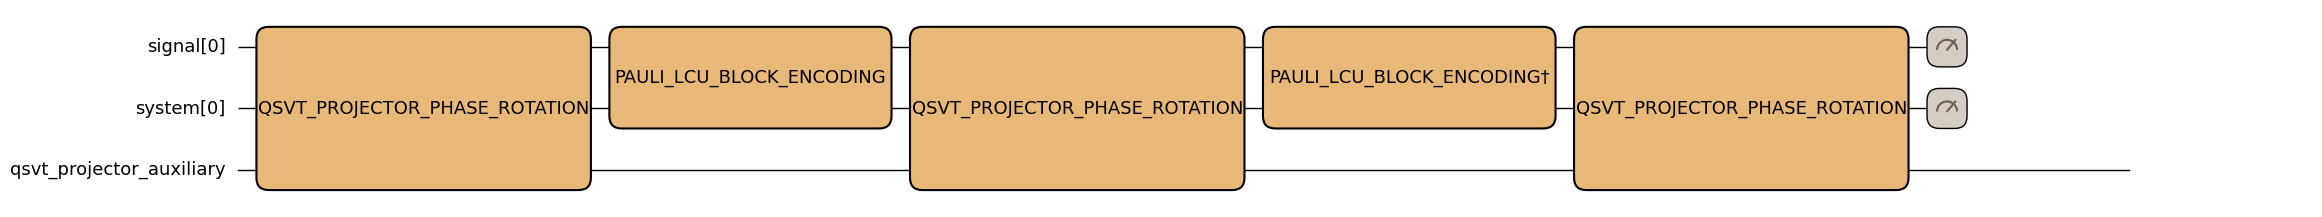

In [6]:
qsvt_phases = [0.0, -math.pi / 2.0, math.pi / 2.0]
singular_value_transform.draw(
    encoding=block_encoding,
    phases=qsvt_phases,
    fold_loops=False,
)

In [7]:
transpiler = QiskitTranspiler()
qsvt_circuit = transpiler.to_circuit(
    singular_value_transform,
    bindings={
        "encoding": block_encoding,
        "phases": qsvt_phases,
    },
).remove_final_measurements(inplace=False)

Qiskitへ変換した回路は、次のセクションの数値検証に使います。ユニタリを調べられるように最終測定を`qsvt_circuit`からのみ削除しており、元の量子カーネルの定義には測定が含まれています。

## 実行結果

QSVTユニタリ全体から信号レジスタの全量子ビットが0であるブロックを取り出し、$2A^\dagger A-I$と比較します。

In [8]:
def projected_signal_block(
    unitary: np.ndarray,
    signal_width: int,
    system_width: int,
) -> np.ndarray:
    """Extract the all-zero-signal block from a unitary matrix.

    Args:
        unitary (np.ndarray): Full circuit unitary.
        signal_width (int): Number of low-order signal qubits.
        system_width (int): Number of system qubits.

    Returns:
        np.ndarray: Projected matrix acting on the system register.
    """
    system_dimension = 1 << system_width
    projected_indices = np.arange(system_dimension) << signal_width
    return unitary[np.ix_(projected_indices, projected_indices)]


qsvt_unitary = np.asarray(Operator(qsvt_circuit).data)
actual_transform = projected_signal_block(
    qsvt_unitary,
    block_encoding.num_signal_qubits,
    block_encoding.num_system_qubits,
)
normalized_matrix = matrix / block_encoding.normalization
expected_transform = (
    2.0 * normalized_matrix.conj().T @ normalized_matrix
    - np.eye(1 << block_encoding.num_system_qubits)
)

np.testing.assert_allclose(
    actual_transform,
    expected_transform,
    rtol=0.0,
    atol=1e-8,
)
print("QSVT projected block:\n", np.round(actual_transform, decimals=8))

QSVT projected block:
 [[-1.+0.j  0.+0.j]
 [ 0.+0.j  1.-0.j]]


QSVTの実装では、射影位相回転に1つの補助量子ビットを使います。この量子ビットは0へ戻る必要があるため、射影された入力から補助量子ビットが1である部分空間への振幅はありません。

In [9]:
logical_dimension = 1 << (
    block_encoding.num_signal_qubits + block_encoding.num_system_qubits
)
projected_input_indices = (
    np.arange(1 << block_encoding.num_system_qubits)
    << block_encoding.num_signal_qubits
)
auxiliary_one_indices = np.arange(logical_dimension) + logical_dimension

np.testing.assert_allclose(
    qsvt_unitary[np.ix_(auxiliary_one_indices, projected_input_indices)],
    0.0,
    rtol=0.0,
    atol=1e-8,
)

$A$の2つの特異値は$1$と$0$です。この多項式はそれぞれを$1$と$-1$へ写し、射影したブロックで得られた結果と一致します。

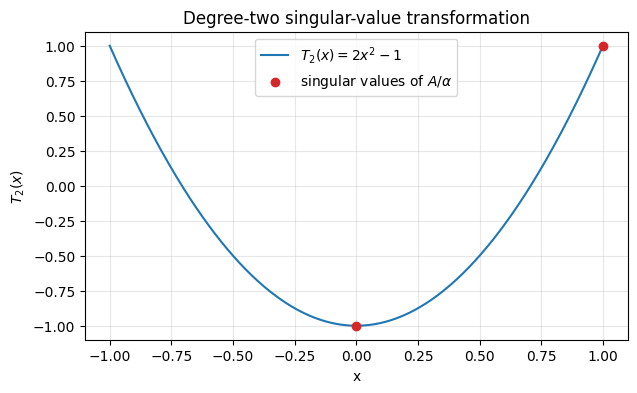

In [10]:
polynomial_x = np.linspace(-1.0, 1.0, 400)
polynomial_y = 2.0 * polynomial_x**2 - 1.0
singular_values = np.linalg.svd(normalized_matrix, compute_uv=False)
transformed_singular_values = 2.0 * singular_values**2 - 1.0

fig, axis = plt.subplots(figsize=(7, 4))
axis.plot(polynomial_x, polynomial_y, label=r"$T_2(x)=2x^2-1$")
axis.scatter(
    singular_values,
    transformed_singular_values,
    color="tab:red",
    zorder=3,
    label="singular values of $A/\\alpha$",
)
axis.set_xlabel("x")
axis.set_ylabel("$T_2(x)$")
axis.set_title("Degree-two singular-value transformation")
axis.grid(alpha=0.3)
axis.legend()
plt.show()

## リソース推定

### 問い合わせ計算量

GilyénらによるQSVTの回路構成{cite:p}`10.1145/3313276.3316366`（3.2節、図1）では、$d$次の変換に$U$と$U^\dagger$を合計$d$回、射影位相回転を$d+1$回用います。したがって、ブロックエンコーディングに対する問い合わせ計算量は$\Theta(d)$です。必要な次数$d$は、目標関数、近似区間、許容誤差、正規化係数$\alpha$によって決まります。

$U$と$U^\dagger$の費用を同じ$G_U$とみなし、1回の射影位相回転の費用を$G_\Pi(a)$とすると、測定などの後処理を除くゲート数は次のように整理できます。

$$
G_{\mathrm{QSVT}}\simeq dG_U+(d+1)G_\Pi(a).
$$

第1項はブロックエンコーディングの呼び出し、第2項は位相回転の費用です。これは文献の回路構成に基づく費用の内訳であり、実行先での一意なゲート数ではありません。$G_U$はLCUやスパースオラクルなどの実装方法に、$G_\Pi(a)$は多重制御ゲートの分解方法に依存します。

### この例の論理リソース

Qamomileのリソース推定機能では、同じ量子カーネルにブロックエンコーディングと位相ベクトルを指定できます。推定結果は、実行先に依存しないQamomileの論理ゲート基底で表されます。

In [11]:
estimate = singular_value_transform.estimate_resources(
    inputs={
        "encoding": block_encoding,
        "phases": qsvt_phases,
    }
)

print("logical qubits:", estimate.qubits)
print("logical gates:", estimate.gates.total)
print("logical depth:", estimate.depth.depth)
print("estimate quality:", estimate.quality.value)

expected_qubits = (
    block_encoding.num_signal_qubits
    + block_encoding.num_system_qubits
    + 1
)
assert estimate.qubits == expected_qubits
assert estimate.gates.total == 25
assert estimate.depth.depth == 27
assert estimate.quality.value == "upper_bound"

logical qubits: 3
logical gates: 25
logical depth: 27
estimate quality: upper_bound


3つの論理量子ビットは、1つの信号量子ビット、1つの系量子ビット、1つの再利用可能な射影用補助量子ビットです。この例では$d=2$なので、理論上は$U$を1回、$U^\dagger$を1回、射影位相回転を3回適用します。上に表示される論理ゲート数と回路深さは、これらの処理を選択したパウリLCUブロックエンコーディングとQamomileの論理ゲート基底で展開した結果です。同じ抽象度にそろえることで、理論的な内訳と推定値を比較できます。

実行先へ変換すると、多重制御ゲートや回転は、ゲート集合、量子ビット間の接続、回路合成の設定に応じてさらに分解されます。特定の実行先に対するゲート数としては有用ですが、これらの実装条件を考慮せずにブロックエンコーディングの問い合わせ回数と直接比較することはできません。

## まとめ

本記事では、次の内容を扱いました。

- 非エルミート行列のパウリLCUブロックエンコーディングを構築しました。
- 2次のQSVT位相列を適用し、偶関数の特異値変換$2(A/\alpha)^\dagger(A/\alpha)-I$と一致することを確認しました。
- 次数に応じたブロックエンコーディングの問い合わせ回数を導出し、同じQamomile量子カーネルについて、実行先に依存しない論理量子ビット数、ゲート数、回路深さを推定しました。

Qamomileの`qmc.qsvt`は、利用者が与えた射影位相列からQSVT回路を構成します。位相合成、近似区間の選択、他のQSP規約からの変換は、別の古典的な前処理として行う必要があります。